# Group 3 - Applied Machine Learning Final Project

https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive, files
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline

## Data Extraction/Processing and EDA

In [ ]:
# Adding dataset to the notebook through drive
drive.mount('/content/drive')

# Replace path in here with any location from either local files or drive
df = pd.read_csv("/content/drive/MyDrive/datasets/heart_2022_with_nans.csv")
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Mounted at /content/drive
Shape: 445,132 rows × 40 columns


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes


In [ ]:
#Exploratory Overview
print(df['HadHeartAttack'].value_counts())
print(f"\nPositive rate: {(df['HadHeartAttack'] == 'Yes').mean():.2%}")

missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
        [missing > 0].to_string())

HadHeartAttack
No     416959
Yes     25108
Name: count, dtype: int64

Positive rate: 5.64%
                           Missing Count  Missing %
TetanusLast10Tdap                  82516       18.5
PneumoVaxEver                      77040       17.3
HIVTesting                         66127       14.9
ChestScan                          56046       12.6
CovidPos                           50764       11.4
HighRiskLastYear                   50623       11.4
BMI                                48806       11.0
FluVaxLast12                       47121       10.6
AlcoholDrinkers                    46574       10.5
WeightInKilograms                  42078        9.5
ECigaretteUsage                    35660        8.0
SmokerStatus                       35462        8.0
HeightInMeters                     28652        6.4
DifficultyErrands                  25656        5.8
DifficultyConcentrating            24240        5.4
DifficultyWalking                  24012        5.4
DifficultyDressingBathing

In [ ]:
# Inspect the features of the dataset to see all features, their data types and non null counts, and shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

In [ ]:
# Preprocessing

# Handle target variable
df['target'] = (df['HadHeartAttack'] == 'Yes').astype(int)
df.drop(columns=['HadHeartAttack'], inplace=True)

# Handle missing values
thresh = 0.4 * len(df)
df.dropna(thresh=len(df) - thresh, axis=1, inplace=True)

num_cols = df.select_dtypes(include='number').columns.drop('target').tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna('Unknown')

# Replace categorical values with integers
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Scale the numerical columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print(f'{len(num_cols)} numeric, {len(cat_cols)} categorical features ready.')

6 numeric, 33 categorical features ready.


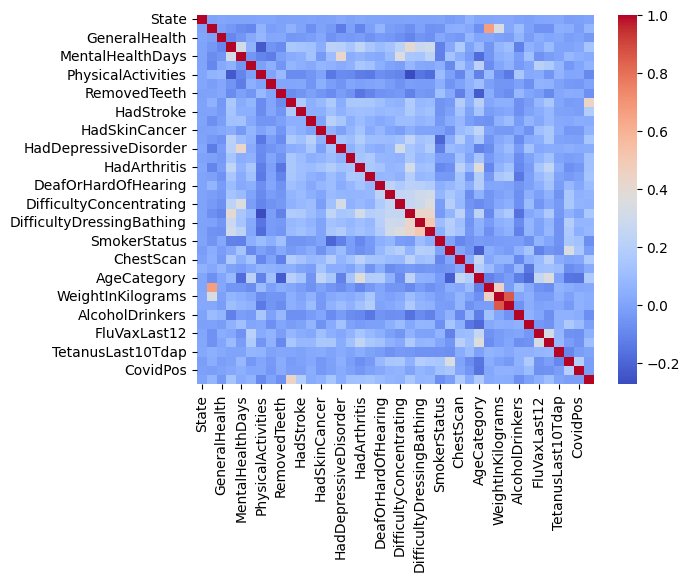

In [ ]:
# Create a correlation matrix to see if we have redundant features and to preven
# multicollinearity for our models
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

When looking at the correlation matrix for the features in the dataset, we can see
that there is mostly low to no correlation at all between features. Having low to no correlation is
good for our modeling for linear models such as logistic regression and SVM since it
heavily reduces multicollinearity, meaning that they are not linearly dependent on
one another which ultimately will help make these models more stable and
interpretable. Our tree based models like decision trees and random forests do not
necessarily get impacted by correlation in the first place since they inherently deal
with redundant and low importance features.

In [ ]:
# Downsampling to a 1:1 ration because of highly imbalanced target variable
# Only 5% of our data is positive and the remaining are negative (OPTIONAL?)
from sklearn.utils import resample
df_majority = df[df.target == 0]
df_minority = df[df.target == 1]

df_downsample = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df = pd.concat([df_downsample, df_minority])

To handle the extremely large imbalance in our target variable for classes, there are a few solutions we can do but one is downsampling. We reduce the amount of rows that contain the majority class in the target (no heart attack). Roughly 5% of our data is made up of actual heart attack records, this could lead to significant problems where the model doesn't have enough information to accurately determine what is or might not notice it is even there. It would not be able to generalize well enough if it sees new data that is a heart attack.

In [ ]:
# Train/Test Split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Positive rate (train): {y_train.mean():.2%}')

Train: 40,172  |  Test: 10,044
Positive rate (train): 50.00%


## Vincent Bui: Logistic Regression

In [ ]:
# Train Model
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        C=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

pipe.fit(X_train, y_train)
print('Model trained.')

Model trained.


In [ ]:
# Evaluation
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC: {auc:.4f}\n')
print(classification_report(y_test, y_pred,
      target_names=['No Heart Attack', 'Heart Attack']))

ROC-AUC: 0.8816

                 precision    recall  f1-score   support

No Heart Attack       0.78      0.84      0.81      5022
   Heart Attack       0.82      0.76      0.79      5022

       accuracy                           0.80     10044
      macro avg       0.80      0.80      0.80     10044
   weighted avg       0.80      0.80      0.80     10044



In [ ]:
# Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'Fold scores: {cv_scores.round(4)}')
print(f'Mean ± Std:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Fold scores: [0.8814 0.8846 0.8804 0.8913 0.89  ]
Mean ± Std:  0.8855 ± 0.0044


In [ ]:
# Odds Ratios
coef = pipe.named_steps['clf'].coef_[0]
odds = np.exp(coef)

coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': coef,
    'OddsRatio':   odds
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.head(15).to_string(index=False))


                Feature  Coefficient  OddsRatio
              HadAngina     1.178419   3.249233
            AgeCategory     0.618153   1.855498
              HadStroke     0.384108   1.468304
                    Sex     0.365706   1.441532
              ChestScan     0.319323   1.376196
           SmokerStatus    -0.203145   0.816160
            HadDiabetes     0.167052   1.181816
        AlcoholDrinkers    -0.127675   0.880139
                HadCOPD     0.105668   1.111453
     PhysicalHealthDays     0.102061   1.107450
           RemovedTeeth    -0.096904   0.907643
        LastCheckupTime     0.089104   1.093195
      DifficultyWalking     0.080749   1.084099
BlindOrVisionDifficulty     0.078776   1.081962
          GeneralHealth    -0.075383   0.927388


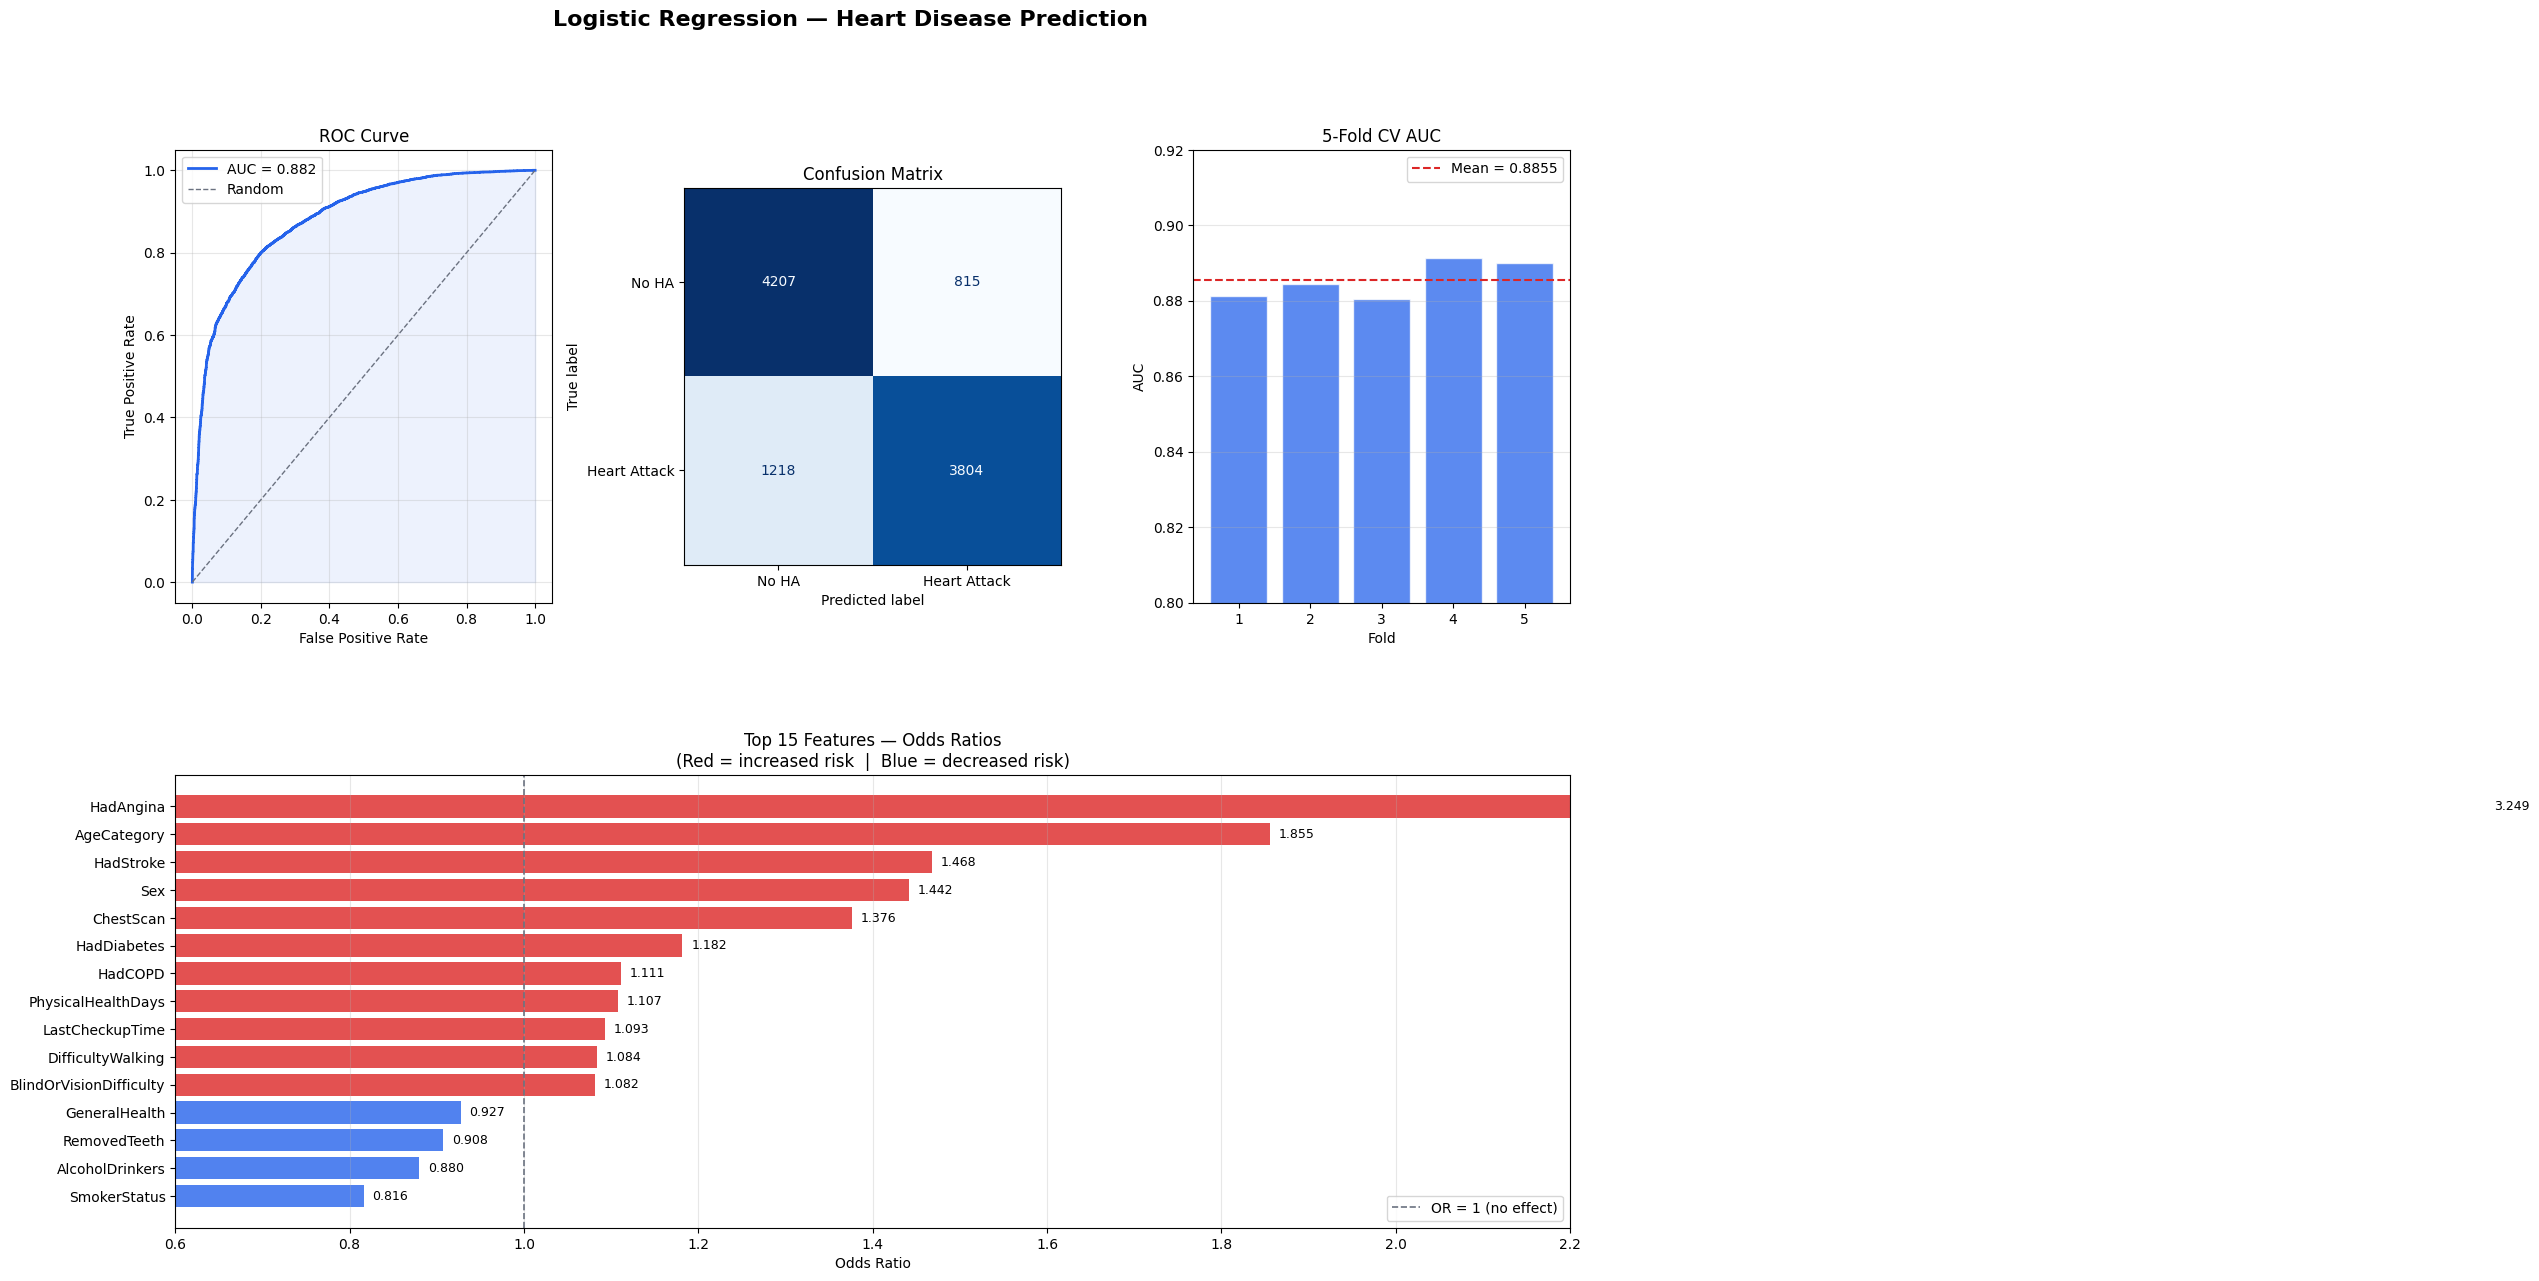

In [ ]:
# Plots
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

BLUE, RED, GRAY = '#2563EB', '#DC2626', '#6B7280'

#ROC Curve
ax0 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax0.plot(fpr, tpr, color=BLUE, lw=2, label=f'AUC = {auc:.3f}')
ax0.plot([0,1],[0,1], color=GRAY, lw=1, linestyle='--', label='Random')
ax0.fill_between(fpr, tpr, alpha=0.08, color=BLUE)
ax0.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
ax0.legend(); ax0.grid(alpha=0.3)

#Confusion Matrix
ax1 = fig.add_subplot(gs[0, 1])
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
    display_labels=['No HA', 'Heart Attack']).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix')

#CV AUC Bar Chart
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(range(1, 6), cv_scores, color=BLUE, alpha=0.75, edgecolor='white')
ax2.axhline(cv_scores.mean(), color=RED, lw=1.5, linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
ax2.set(xlabel='Fold', ylabel='AUC', title='5-Fold CV AUC')
ax2.set_ylim([0.80, 0.92]); ax2.legend(); ax2.grid(axis='y', alpha=0.3)

#Top 15 Features
ax3 = fig.add_subplot(gs[1, :])
top15 = coef_df.head(15).sort_values('OddsRatio')
colors = [RED if o >= 1 else BLUE for o in top15['OddsRatio']]
bars = ax3.barh(top15['Feature'], top15['OddsRatio'], color=colors, alpha=0.8)
ax3.axvline(x=1.0, color=GRAY, lw=1.2, linestyle='--', label='OR = 1 (no effect)')
for bar, val in zip(bars, top15['OddsRatio']):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax3.set(xlabel='Odds Ratio',
        title='Top 15 Features — Odds Ratios\n(Red = increased risk  |  Blue = decreased risk)')
ax3.set_xlim([0.6, 2.2]); ax3.legend(); ax3.grid(axis='x', alpha=0.3)

plt.suptitle('Logistic Regression — Heart Disease Prediction', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_lr_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Luke Ladas: Decision Tress & Random Forest

### Decision Tree Modeling

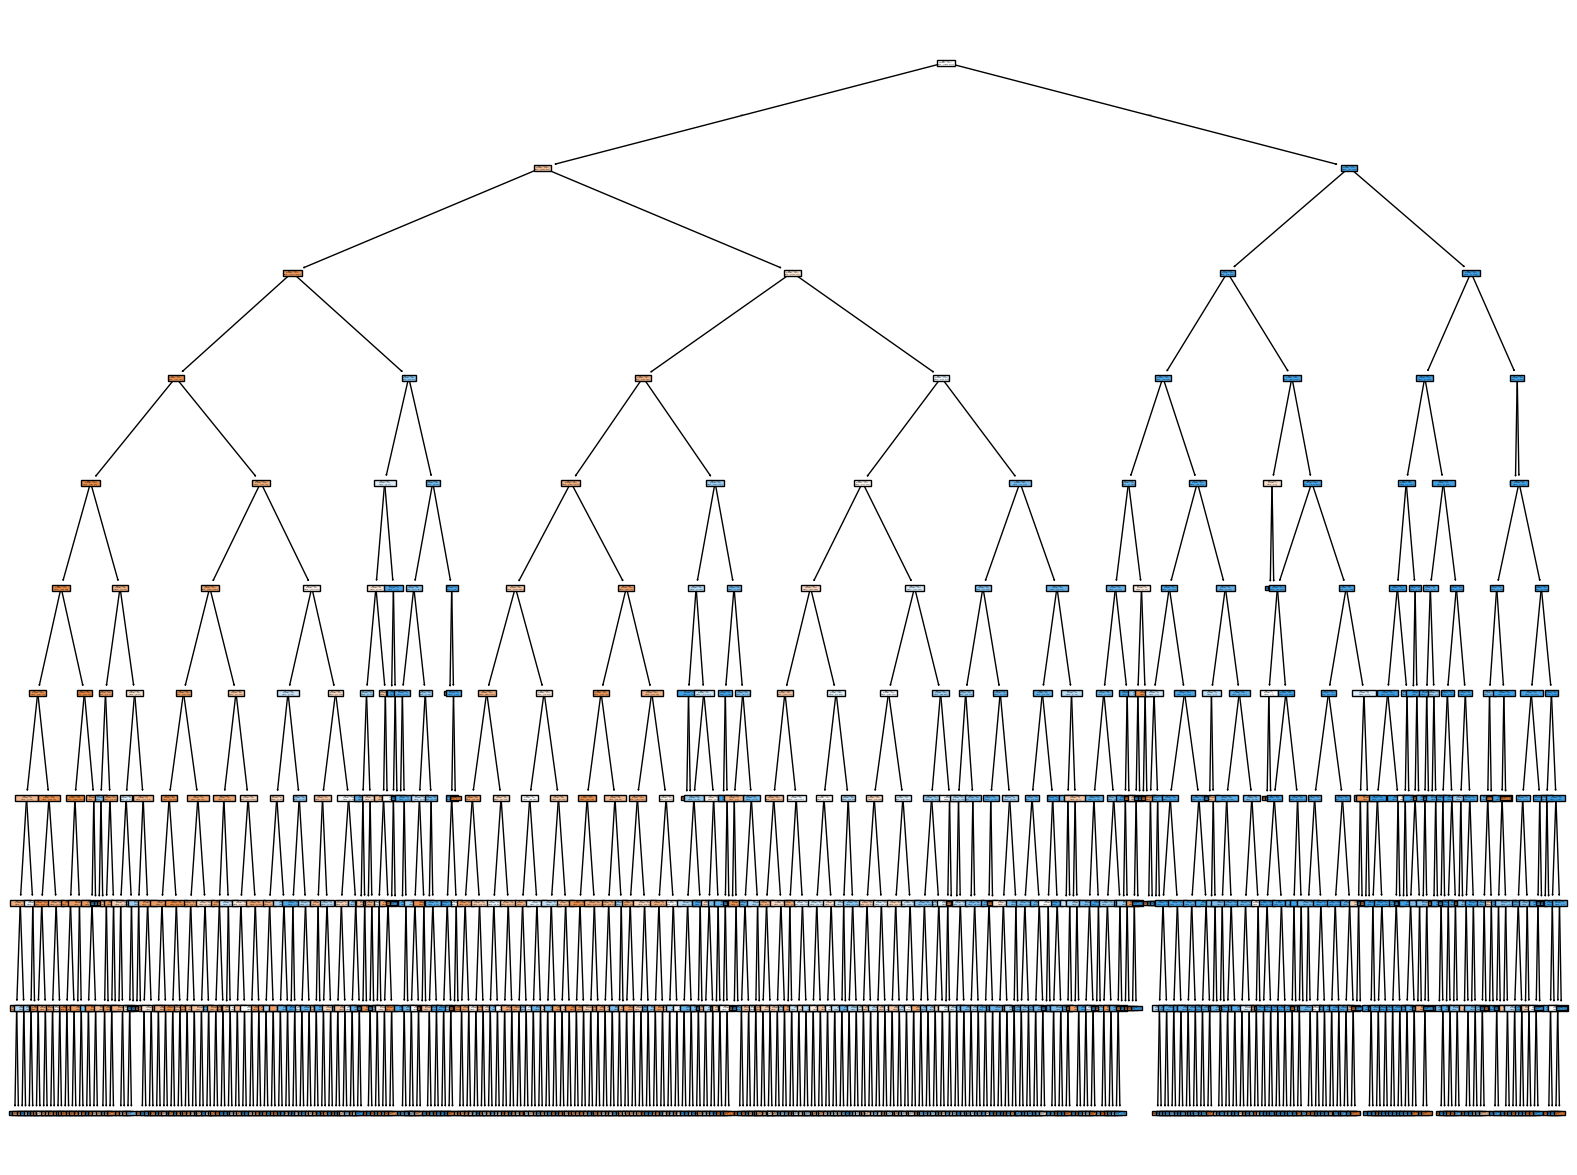

In [ ]:
# Fit and model a decision tree (no pruning yet)
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth = 10, random_state=42)
tree.fit(X_train, y_train)

plt.figure(figsize=(20,15))
plot_tree(tree, feature_names=X_train.columns, filled=True)
plt.show()

The decision tree we have is extremely large with many leaf nodes and branching paths and is ultimately highly complex and complicated, we are going to prune the decision tree since this large tree could lead to overfitting and poor performance.

In [ ]:
# Prune the decision tree to maximize performance and reducing overfitting it also tells us what features are important and worth keeping
# We want to use random search cross validation to find the most optimal parameters to prune our tree because of the large dataset
from sklearn.model_selection import RandomizedSearchCV

params = {
    'max_depth': [5, 10, 15, 25, None],
    'max_leaf_nodes': [20, 50, 100, 200],
    'min_samples_split': [2, 10, 50, 100],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    tree,
    param_distributions=params,
    n_iter=75,
    cv=cv,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

{'min_samples_split': 50, 'min_samples_leaf': 20, 'max_leaf_nodes': 100, 'max_depth': 15, 'criterion': 'gini'}


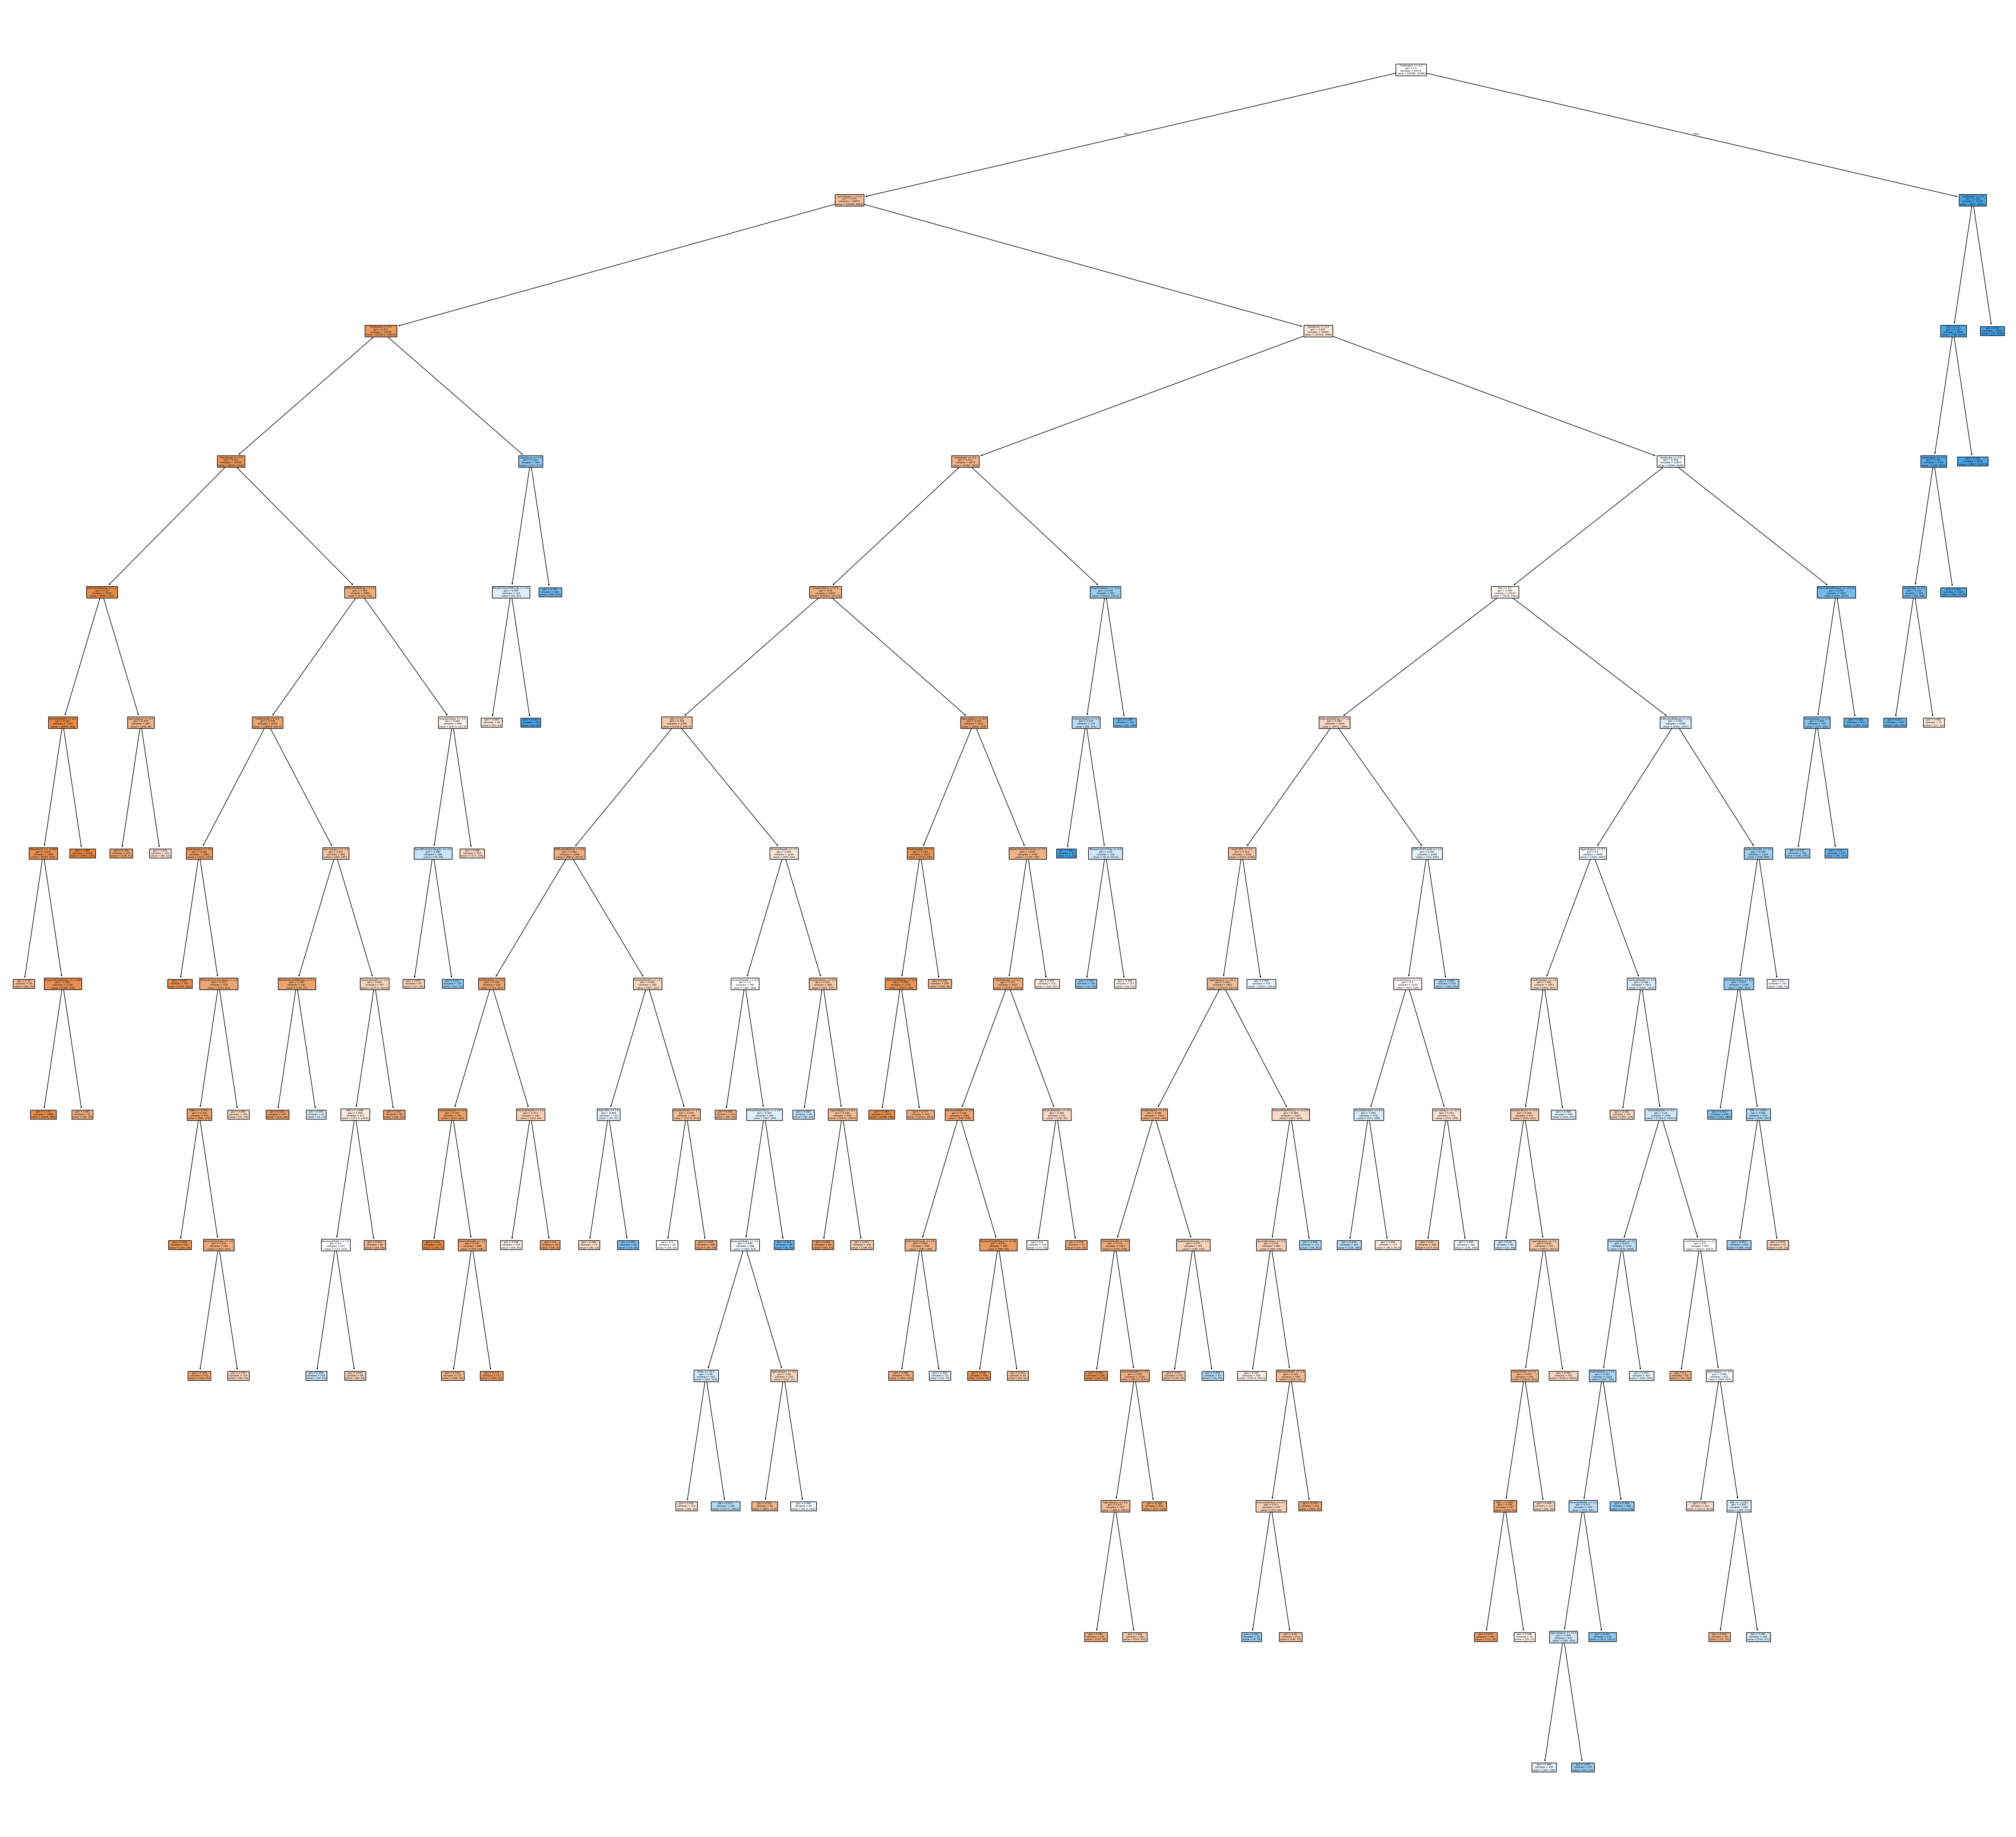

In [ ]:
# Perform the model with the new parameter tuning
tree = DecisionTreeClassifier(min_samples_split=50, min_samples_leaf = 20, max_leaf_nodes = 100, max_depth = 15, criterion = 'gini', class_weight="balanced", random_state=42)
tree.fit(X_train, y_train)

plt.figure(figsize=(60,55))
plot_tree(tree, feature_names=X_train.columns, filled=True)
plt.show()

The decision tree is a lot easier to read and understand with pruning taken into account. This should lead to better results in regards to performance and accuracy and less overfitting since the model is not as complex. It also helps us reduce features that might not be relevant for prediction

In [ ]:
# Feature Importances
importances = tree.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

print(feature_importance)

                      feature  importance
9                   HadAngina    0.623114
28                AgeCategory    0.142519
10                  HadStroke    0.065176
26                  ChestScan    0.063402
21          DifficultyWalking    0.023983
1                         Sex    0.016523
2               GeneralHealth    0.012154
24               SmokerStatus    0.011205
17                HadDiabetes    0.007940
8                RemovedTeeth    0.005587
13                    HadCOPD    0.003816
16               HadArthritis    0.003469
3          PhysicalHealthDays    0.003274
31                        BMI    0.002954
32            AlcoholDrinkers    0.002275
23          DifficultyErrands    0.001904
18        DeafOrHardOfHearing    0.001889
19    BlindOrVisionDifficulty    0.001521
35              PneumoVaxEver    0.001236
20    DifficultyConcentrating    0.000872
4            MentalHealthDays    0.000827
7                  SleepHours    0.000820
27      RaceEthnicityCategory    0

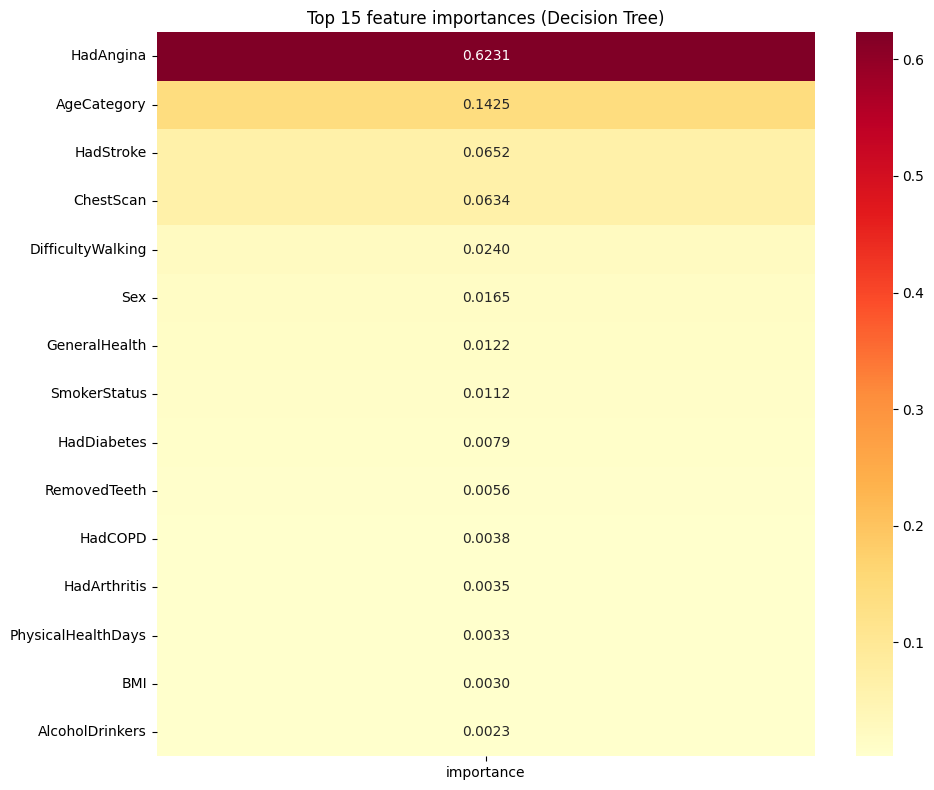

In [ ]:
# Turn the list of importances into a plot (heatmap)
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 8))
sns.heatmap(
    top_features[['importance']],
    annot=True,
    fmt='.4f',
    yticklabels=top_features['feature'],
    cmap='YlOrRd'
)
plt.title('Top 15 feature importances (Decision Tree)')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

We can conclude from this that the top factors
relate to overall health and fitness, which can cause people
to self reflect on their day-to-day life. HadAngina is a significantly high feature which makes sense which it related to having chest discomfort due to a lack of oxygen and blood flow to the heart which can lead to heart disease or potentially already a sign of it existing. HadStroke and ChestScan also relate to this. Overall a lot of these features have to do with underlying health conditions, diet, physical activity and physical qualities.

In [ ]:
# Perform the model on the test set and find probabilities, summarize results and find auc
y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC: {auc:.4f}\n')
print(classification_report(y_test, y_pred,
      target_names=['No Heart Attack', 'Heart Attack']))

ROC-AUC: 0.8733

                 precision    recall  f1-score   support

No Heart Attack       0.79      0.79      0.79      5022
   Heart Attack       0.79      0.79      0.79      5022

       accuracy                           0.79     10044
      macro avg       0.79      0.79      0.79     10044
   weighted avg       0.79      0.79      0.79     10044



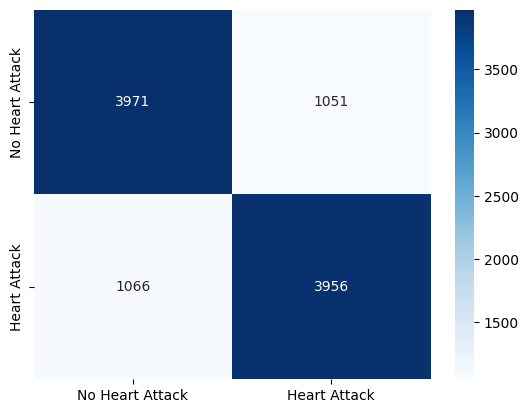

In [ ]:
# create a confusion matrix to determine the true and false positives and negatives for heart attacks/heart disease
# Predictions
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Attack', 'Heart Attack'],
            yticklabels=['No Heart Attack', 'Heart Attack'])
plt.show()

In [ ]:
# Extract each cell in the confusion matrix and calculate the accuracies for heart attacks/disease riusk predicted
TN, FP, FN, TP = matrix.ravel()

# Recall
percent_heart_disease_correct = TP / (TP + FN) * 100
percent_no_risk_correct = TN / (TN + FP) * 100

print(f"percent people with risk of heart disease correctly predicted (on test set): {percent_heart_disease_correct:.2f}%")
print(f"percent people with no risk of heart disease correctly predicted (on test set): {percent_no_risk_correct:.2f}%")

percent people with risk of heart disease correctly predicted (on test set): 78.77%
percent people with no risk of heart disease correctly predicted (on test set): 79.07%


In [ ]:
# Accuracy score calculation
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7892273994424532

After all of this, we get our results of a prediction accuracy of roughly 79% meaning that this percentage is the amount of predictions the model got correct. We also had an area under the curve of 87.33%  which means this percentage is the how well the model can separate between the classes with discrimination. We also had recall, precision, and F1 scores of 79% across the board for heart risk and no heart risk. Meaning 79 percent of patients who predicted as actually having heart risk actually were, 79 percent were correctly identified, and our model is well balanced for false positives and negatives

### Random Forest Modeling

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Fit and run the random forest model using the best parameters from our grid search with decision trees
forest = RandomForestClassifier(n_estimators = 100, min_samples_split=50, min_samples_leaf = 20, max_leaf_nodes = 100, max_depth = 15, criterion = 'gini', class_weight="balanced", random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       max_leaf_nodes=100, min_samples_leaf=20,
                       min_samples_split=50, random_state=42)

In [ ]:
# Feature Importances
importances = forest.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

print(feature_importance)

                      feature  importance
9                   HadAngina    0.396394
28                AgeCategory    0.130989
26                  ChestScan    0.107290
10                  HadStroke    0.061358
8                RemovedTeeth    0.044467
21          DifficultyWalking    0.043618
17                HadDiabetes    0.037646
16               HadArthritis    0.025649
13                    HadCOPD    0.020026
1                         Sex    0.018624
3          PhysicalHealthDays    0.017665
2               GeneralHealth    0.016436
35              PneumoVaxEver    0.016187
24               SmokerStatus    0.012063
18        DeafOrHardOfHearing    0.007047
6          PhysicalActivities    0.005249
29             HeightInMeters    0.004890
15           HadKidneyDisease    0.004476
32            AlcoholDrinkers    0.003998
30          WeightInKilograms    0.003357
5             LastCheckupTime    0.003259
31                        BMI    0.002616
23          DifficultyErrands    0

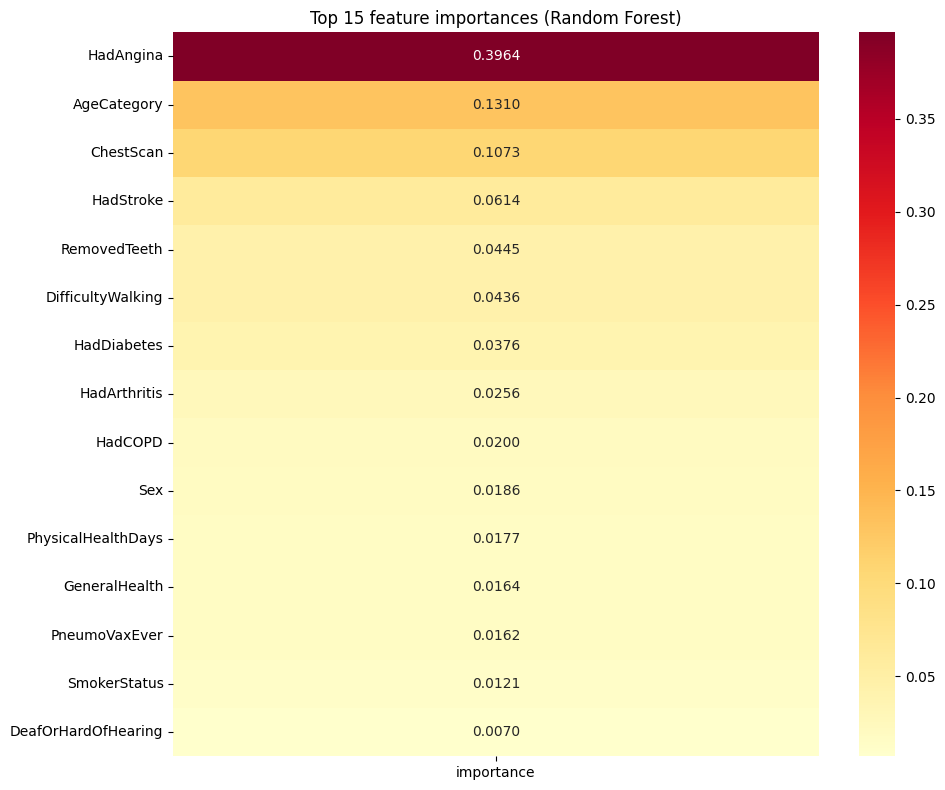

In [ ]:
top_features = feature_importance.head(15)

# Plot heatmap for feature importances
plt.figure(figsize=(10, 8))
sns.heatmap(
    top_features[['importance']],
    annot=True,
    fmt='.4f',
    yticklabels=top_features['feature'],
    cmap='YlOrRd'
)
plt.title('Top 15 feature importances (Random Forest)')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Once again we can conclude from this that the top factors
relate to overall health and fitness, which can cause people
to self reflect on their day-to-day life. HadAngina is again, the significantly highest feature. HadStroke and ChestScan also are high again. A lot of these features still have to do with underlying health conditions, diet, physical activity and physical qualities with some variation.

In [ ]:
# Perform the model on the test set and find probabilities, summarize results and find auc
y_pred = forest.predict(X_test)
y_prob = forest.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC: {auc:.4f}\n')
print(classification_report(y_test, y_pred,
      target_names=['No Heart Attack', 'Heart Attack']))

ROC-AUC: 0.8843

                 precision    recall  f1-score   support

No Heart Attack       0.80      0.81      0.80      5022
   Heart Attack       0.80      0.80      0.80      5022

       accuracy                           0.80     10044
      macro avg       0.80      0.80      0.80     10044
   weighted avg       0.80      0.80      0.80     10044



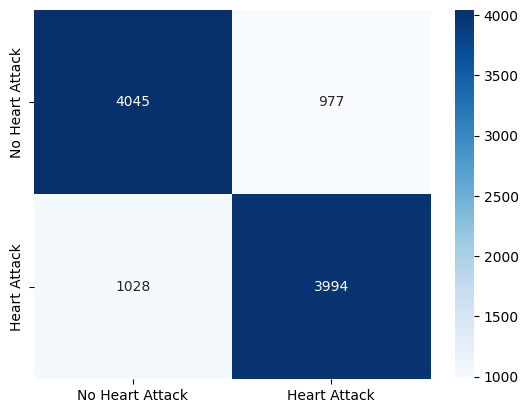

In [ ]:
# create a confusion matrix to determine the true and false positives and negatives for heart attacks/heart disease
# Predictions
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Attack', 'Heart Attack'],
            yticklabels=['No Heart Attack', 'Heart Attack'])
plt.show()

In [ ]:
# Extract each cell in the confusion matrix and calculate the accuracies for heart attacks/disease riusk predicted
TN, FP, FN, TP = matrix.ravel()

percent_heart_disease_correct = TP / (TP + FN) * 100
percent_no_risk_correct = TN / (TN + FP) * 100

print(f"percent people with risk of heart disease correctly predicted (on test set): {percent_heart_disease_correct:.2f}%")
print(f"percent people with no risk of heart disease correctly predicted (on test set): {percent_no_risk_correct:.2f}%")

percent people with risk of heart disease correctly predicted (on test set): 79.53%
percent people with no risk of heart disease correctly predicted (on test set): 80.55%


In [ ]:
# Accuracy score calculation
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8003783353245719

After all of this, we get our results of a prediction accuracy of roughly 80% meaning that this percentage is the amount of predictions the model got correct. We also had an area under the curve of 88.43%  which means this percentage is the how well the model can separate between the classes with discrimination. We also had recall, precision, and F1 scores of 80% across the board for heart risk and no heart risk. Meaning 79 percent of patients who predicted as actually having heart risk actually were, 79 percent were correctly identified, and our model is well balanced for false positives and negatives. This compares very similarly to decision tree which makes sense as the parameters were tuned the same way which already helped with overfitting in the previous scenario.

## Alec Kritta: SVM


                      feature  importance
9                   HadAngina    0.121376
28                AgeCategory    0.017822
10                  HadStroke    0.015880
1                         Sex    0.010633
26                  ChestScan    0.005894
17                HadDiabetes    0.003037
5             LastCheckupTime    0.001294
18        DeafOrHardOfHearing    0.001264
8                RemovedTeeth    0.001264
19    BlindOrVisionDifficulty    0.001245
21          DifficultyWalking    0.001205
32            AlcoholDrinkers    0.000876
2               GeneralHealth    0.000806
24               SmokerStatus    0.000796
20    DifficultyConcentrating    0.000796
11                  HadAsthma    0.000777
16               HadArthritis    0.000687
37           HighRiskLastYear    0.000548
33                 HIVTesting    0.000518
7                  SleepHours    0.000448
13                    HadCOPD    0.000418
35              PneumoVaxEver    0.000388
36          TetanusLast10Tdap    0

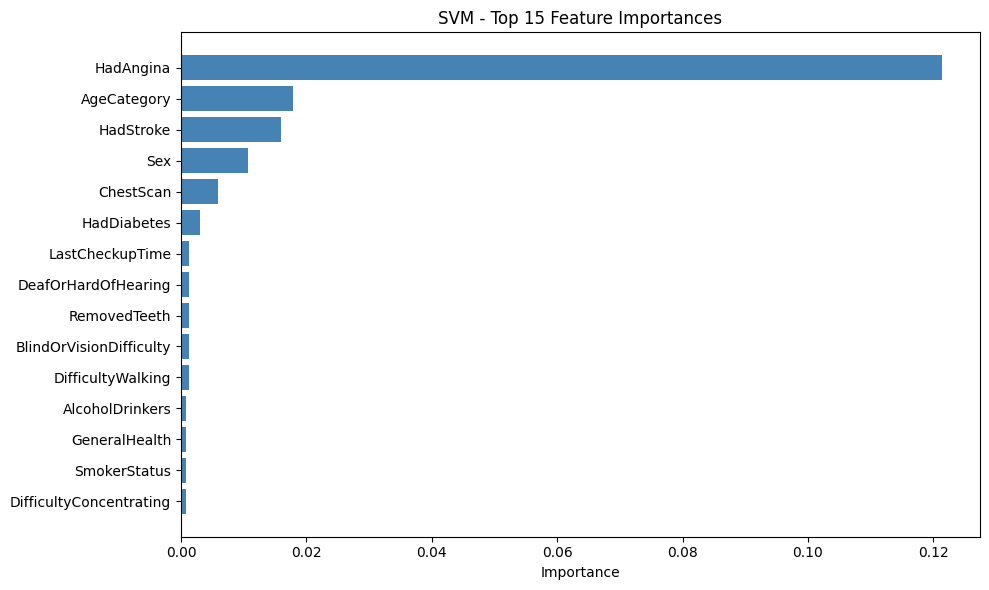

percent people with risk of heart disease correctly predicted: 74.29%
percent people with no risk of heart disease correctly predicted: 85.05%
Overall Accuracy:  0.80
                 precision    recall  f1-score   support

No Heart Attack       0.77      0.85      0.81      5022
   Heart Attack       0.83      0.74      0.79      5022

       accuracy                           0.80     10044
      macro avg       0.80      0.80      0.80     10044
   weighted avg       0.80      0.80      0.80     10044

AUC Score: 0.8817


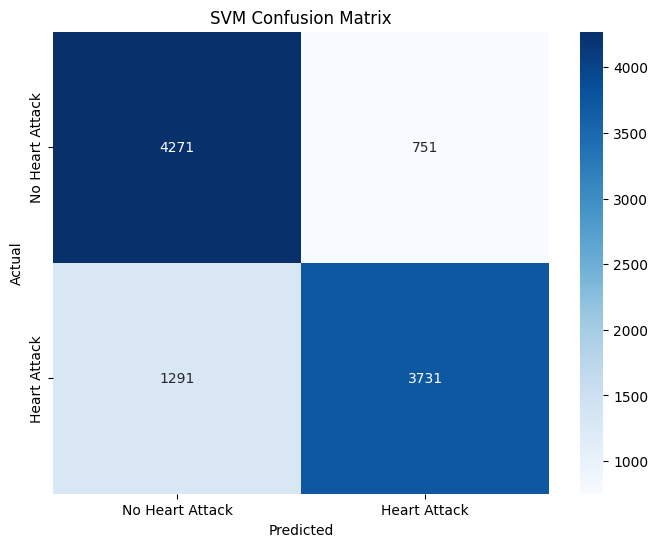

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.inspection import permutation_importance
import seaborn as sns

#Train the linearSVC model with balanced class weights, to handle class imbalances
svm = LinearSVC(C=1.0, random_state=42, max_iter=2000, class_weight='balanced')
svm.fit(X_train, y_train)

#Computer permutation importance for feature contributions to model
p_importance = permutation_importance(svm, X_test, y_test, n_repeats=10, random_state=42)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': p_importance.importances_mean
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)
print(feature_importance)

#Top 15 most important features as bar chart
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('SVM - Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#Predictions on test set and confusion matrix
y_pred = svm.predict(X_test)
matrix = confusion_matrix(y_test, y_pred)
matrix

TN, FP, FN, TP = matrix.ravel()

#Computer % of correct predictions for each class
percent_heart_disease_correct = TP / (TP + FN) * 100
percent_no_risk_correct = TN / (TN + FP) * 100

print(f"percent people with risk of heart disease correctly predicted: {percent_heart_disease_correct:.2f}%")
print(f"percent people with no risk of heart disease correctly predicted: {percent_no_risk_correct:.2f}%")

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred): .2f}")
print(classification_report(y_test, y_pred, target_names=['No Heart Attack', 'Heart Attack']))

auc_score = roc_auc_score(y_test, svm.decision_function(X_test))
print(f"AUC Score: {auc_score:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Attack', 'Heart Attack'],
            yticklabels=['No Heart Attack', 'Heart Attack'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Looking at the SVM model, it proved to be a reliable classifier for the health prediciton task. Along with achieving an overall accuracy of 80% and an AUC score of .8817 which are good indicators of high efficiency. The model also correctly identified 74.29% of individuals with heart disease risk and 85.05% of those without, with balanced precision and recall scores across both classes. Feature importance analysis revealed that HadAngina, AgeCategory, and HadStroke were the most influential predictors, suggesting that prior medical history play a large part in heart attack risk.

## Results Comparison & Conclusion

When looking at our models, we can confidently say that we have high prediction accuracy for being able to determine if someone is at risk of heart disease based on certain high importance features. Using measurements such as recall, precision, roc - auc, and others, we can see that our accuracies and performance are significantly higher than a 50% random selection.

All four models achieve AUC-ROC in the
narrow range of 0.873-0.884 and accuracy of 79-80% on a
balanced 1:1 test set, demonstrating that the survey features
contain strong and consistent predictive signal for heart attack
risk.

All models seem to share similar feature importances which says a lot about how impactful the top features generally are in our dataset. Across all models, we also noticed that ”hadAngina”
was the significantly most prominent feature that determined
whether a person was at risk of heart disease or not. Demographic features ranked low compared to other features too. Prior medical history such as strokes, diabetes and chestscans were also importance acorss our models.

Ultimately,
we can use our models and findings as a relatively accurate
way to signal and determine if a person is at risk of heart
disease and what qualities they have that they can potentially
improve upon to prevent this from happening in the first place.